## Data Preparation
## CRISP-DM – Fase 3

<hr>

In [ ]:
# Importação das libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import os

# Paths do projeto

BASE_DIR = Path().resolve()

DATA_DIR = BASE_DIR / "data"
DATA_PREPARED_DIR = DATA_DIR / "prepared"

OUTPUTS_DIR = BASE_DIR / "outputs"
FIGURES_BASE_DIR = OUTPUTS_DIR / "figures"

FIGURES_UNDERSTANDING_DIR = FIGURES_BASE_DIR / "understanding"
FIGURES_PREPARATION_DIR = FIGURES_BASE_DIR / "preparation"
FIGURES_MODELING_DIR = FIGURES_BASE_DIR / "modeling"

# Criar pastas automaticamente
DATA_PREPARED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_UNDERSTANDING_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_PREPARATION_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_MODELING_DIR.mkdir(parents=True, exist_ok=True)


# Carregar o dataset
DATASET_PATH = BASE_DIR / "HR-Intern-Retention_Dataset.csv"
df_raw = pd.read_csv(DATASET_PATH).drop(["Intern_ID"], axis=1)

<hr>

# One-Hot Encoding (Features Categóricas)

In [8]:
ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded = ohe.fit_transform(df_raw[["Major", "Department"]])

# 2. Criar DataFrame das novas colunas com nomes adequados
encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(["Major", "Department"]),
    index=df_raw.index # Garante o alinhamento perfeito no concat
)

# 3. Concatenar horizontalmente (axis=1)
df_onehot = pd.concat([df_raw.drop(["Major", "Department"], axis=1), encoded_df], axis=1)

df_onehot.head()

,Age,Internship_Duration_Months,Supervisor_Evaluation,Salary,Attendance_%,Retained,Major_Engineering,Major_IT,Major_Law,Major_Marketing,Department_HR,Department_IT,Department_Legal,Department_Marketing
0,24,20,1.8,1956,71.9,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,21,15,1.2,1687,82.7,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,28,3,1.7,926,79.0,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,25,23,2.1,1929,86.5,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,22,8,1.7,1808,97.5,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


- #### Verificar se alguma das novas colunas tem correlação com o Salário.

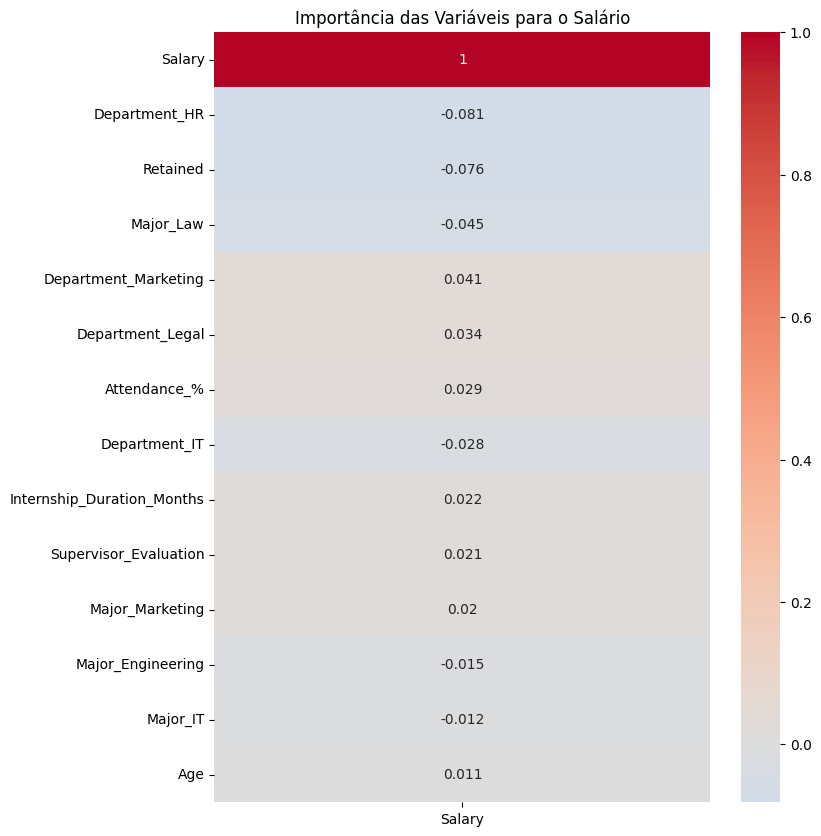

In [9]:
# Calcular correlações
corr_matrix = df_onehot.corr()[['Salary']]

# Criar uma coluna temporária com o valor absoluto para ordenar
corr_matrix['abs_corr'] = corr_matrix['Salary'].abs()

# Ordenar pelo valor absoluto (do mais forte para o mais fraco)
salary_corr_sorted = corr_matrix.sort_values(by='abs_corr', ascending=False).drop('abs_corr', axis=1)

# Plot
plt.figure(figsize=(8, 10))
sns.heatmap(salary_corr_sorted, annot=True, cmap='coolwarm', center=0)
plt.title('Importância das Variáveis para o Salário')

plt.savefig(FIGURES_PREPARATION_DIR / "importancia_variaveis_salario.png", bbox_inches="tight")
plt.show()


- Reforça a nossa conclusão anterior: não há nenhuma variável que influencie o salário de forma clara.

<hr>

# Scaling

- Para evitar que o nosso modelo pese as variáveis de maneira diferente consoante os seus valores, utilizamos o StandardScaler transformando os dados para que a média seja $0$ e o desvio padrão seja $1$.

- **Divisão antes do Scaling**:
    - O scaler não deve ser ajustado ao conjunto de dados completo.
    - Primeiro, deve-se dividir os dados em treino e teste.
    - O ajuste do scaler é feito exclusivamente com os dados de treino, sendo depois aplicado ao conjunto de teste.
    - Esta abordagem evita data leakage (fuga de informação), garantindo uma avaliação mais fiável e representativa do desempenho do modelo.

In [10]:
# 1. Definir colunas para Scaling: Apenas variáveis contínuas com escalas distintas.
# Excluímos Dummies e Retained pois já são binárias (0/1). O Target (Salary) nunca é normalizada para manter a unidade monetária.
num_cols = ['Age', 'Internship_Duration_Months', 'Attendance_%', 'Supervisor_Evaluation']

# 2. Separação de Features (X) e Target (y):
# EXCLUSÃO CRÍTICA: 'Retained' é removida por ser uma variável de "pós-evento". 
# Incluí-la causaria Data Leakage, pois na vida real não sabemos se um estagiário será retido no momento em que definimos o seu salário inicial.
X = df_onehot.drop(['Salary', 'Retained'], axis=1) 
y = df_onehot['Salary']

# 3. Divisão Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Inicializar o Scaler
scaler = StandardScaler()

# 5. Fit & Transform no TREINO: O scaler aprende a média e desvio padrão APENAS do treino.
# Isto garante que nenhuma informação (distribuição) do conjunto de teste "vaze" para o treino.
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# 6. Transform no TESTE: Aplicamos a escala aprendida no treino aos dados de teste.
# Tratamos os dados de teste como "dados novos/futuros", sem recalcular parâmetros de escala (Prevenção de Data Leakage).
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Visualização do conjunto de treino final pronto para modelação
X_train.head()

,Age,Internship_Duration_Months,Supervisor_Evaluation,Attendance_%,Major_Engineering,Major_IT,Major_Law,Major_Marketing,Department_HR,Department_IT,Department_Legal,Department_Marketing
79,0.849471,-1.678929,-0.346226,-1.046747,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
197,-1.742135,0.083533,1.362421,-1.290886,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
38,-1.166222,0.964765,0.103418,0.392833,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
24,1.425383,1.405381,-0.436154,0.510693,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
122,-0.014398,0.817893,1.632207,-1.046747,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


### Validação da Transformação de Scaling

In [11]:
# 1. Verificar Médias e Desvios Padrão após Scaling
print("--- Validação da Transformação: Médias e DP (Treino) ---")
stats = X_train[num_cols].agg(['mean', 'std']).round(2)
display(stats)

# 2. Verificar se o Alinhamento X e y se mantém
print(f"\n--- Shape Check ---")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

# 3. Garantir que não há NaNs "fantasma"
if X_train.isna().sum().sum() == 0:
    print("\nCheck: Dados limpos e sem valores nulos.")

--- Validação da Transformação: Médias e DP (Treino) ---


,Age,Internship_Duration_Months,Attendance_%,Supervisor_Evaluation
mean,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0



--- Shape Check ---
X_train: (160, 12) | y_train: (160,)
X_test:  (40, 12)  | y_test:  (40,)

Check: Dados limpos e sem valores nulos.


<hr>

## Guardar Dados

In [12]:
# Guardar Dados Preparados

X_train.to_csv(DATA_PREPARED_DIR / "X_train_scaled.csv", index=False)
X_test.to_csv(DATA_PREPARED_DIR / "X_test_scaled.csv", index=False)
y_train.to_csv(DATA_PREPARED_DIR / "y_train.csv", index=False)
y_test.to_csv(DATA_PREPARED_DIR / "y_test.csv", index=False)

print("✅ Todos os ficheiros foram guardados com sucesso em data/prepared/")

✅ Todos os ficheiros foram guardados com sucesso em data/prepared/


<hr>

## Síntese da Fase de Data Preparation

Nesta fase, os dados foram preparados com o objetivo de garantir robustez estatística e estabilidade matemática no modelo de Regressão.

- **Codificação Categórica**  
  Aplicou-se *One-Hot Encoding* às variáveis categóricas (ex.: `Major`, `Department`), utilizando `drop='first'` para evitar multicolinearidade (Dummy Variable Trap).

- **Prevenção de Data Leakage**  
  A variável `Retained` foi excluída do conjunto de preditores, por representar informação futura face ao target (`Salary`). Esta decisão assegura que o modelo é utilizável em cenários reais de previsão.

- **Normalização (Scaling)**  
  Foi utilizado o `StandardScaler` nas variáveis numéricas contínuas (ex.: `Age`, `Attendance_%`).  
  O *fit* foi realizado exclusivamente sobre o conjunto de treino, sendo depois aplicado ao conjunto de teste, evitando fuga de informação.

- **Divisão dos Dados**  
  O dataset foi dividido em:
  - 80% para treino  
  - 20% para teste  
  Utilizou-se `random_state=42` para garantir reprodutibilidade.

- **Estado Atual**  
  O dataset encontra-se:
  - Validado (média ≈ 0 e desvio padrão ≈ 1 nas variáveis escaladas)  
  - Pronto para a fase de modelação